In [63]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import os,cv2
from scipy.optimize import fmin
from scipy.ndimage import affine_transform
import shutil
from scipy.io import readsav
import glob
from matplotlib.patches import Rectangle
from scipy.ndimage import zoom
from gaussian_fit import fit_gaussian, fit_double_gaussian
import matplotlib.ticker as ticker

这个文档是最终，计划用OI CI来做波长定标

Text(0.5, 1.0, 'Active region to calculate reference wavelength T21:04:35')

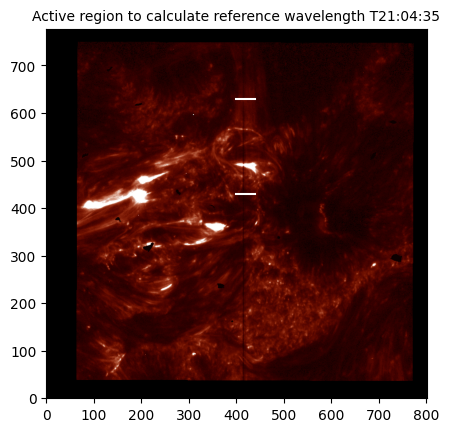

In [25]:
rsm_1400=fits.open(r'C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_SJI_1400_t000.fits')
sji1400=rsm_1400[0].data
new_map=np.log(sji1400[785,:,:]+201)#对应时间21：04：35

plt.imshow(new_map,origin='lower',cmap='irissji1400',vmin=5.3,vmax=5.8)
plt.plot([400, 440], [430, 430], linestyle='-', color='white')
plt.plot([400, 440], [630, 630], linestyle='-', color='white')
plt.title('Active region to calculate reference wavelength T21:04:35', fontsize=10)

bright pass 0: replaced 679 pixels
bright pass 1: replaced 88 pixels
bright pass 2: replaced 23 pixels
bright pass 3: replaced 13 pixels
bright pass 4: replaced 2 pixels
bright pass 5: replaced 1 pixels
bright pass 6: replaced 0 pixels
dark pass 0: replaced 2 pixels
dark pass 1: replaced 0 pixels
787
有多少个NaN值 1281
拟合得到的OI多普勒速度为 15.288510006325955 km/s
拟合得到的CI多普勒速度为 13.684873225971208 km/s


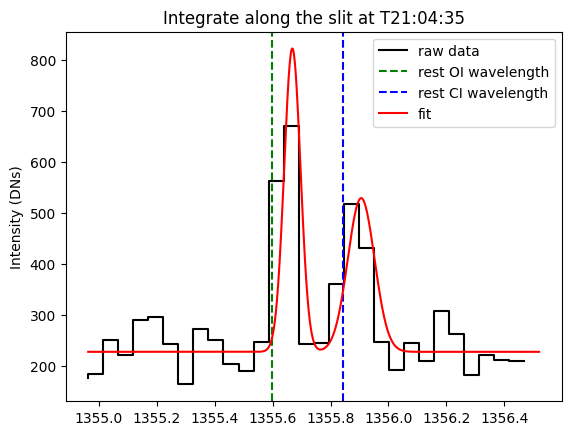

In [101]:
file_list=glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_raster\*.fits')
rsm=fits.open(file_list[392])#对应时间21：04：35
spectrum=rsm[2].data[4,:,:]
exptime=rsm[0].header['EXPTIME']
from array_despike import array_despike
#IRIS会将一些NaN设置为-200
valid_mask = (
    np.isfinite(spectrum)
    & (spectrum != -200)
)

spectrum_clean, info = array_despike(
    spectrum,
    sigma=8.0,
    threshold=6.0,
    itmax=20,
    no_low=False,
    valid_mask=valid_mask,
    return_info=True,
    verbose=True,
)

print(info["n_changed_unique"])
wave_x=np.arange(rsm[2].header['CRVAL1'], 
                 rsm[2].header['CRVAL1'] + rsm[2].header['NAXIS1'] * rsm[2].header['CDELT1'], 
                 rsm[2].header['CDELT1'])


selected = spectrum_clean[430:630, :]
selected = selected.astype(float)
print('有多少个NaN值',np.count_nonzero(selected == -200))
selected[selected == -200] = np.nan
wave_y1 = np.nansum(selected, axis=0)
#wave_y1=wave_y1/exptime
#wave_y1=(np.vstack((spectrum_clean[100:300,:],spectrum_clean[550:700,:]))).sum(axis=0)
start_point,end_point=155,185
plt.step(wave_x[start_point:end_point],wave_y1[start_point:end_point],
         label='raw data',color='black')
plt.axvline(x=1355.599,linestyle='--',color='green',label='rest OI wavelength')
plt.axvline(x=1355.844,linestyle='--',color='blue',label='rest CI wavelength')
plt.ylabel(r"Intensity (DNs)")
plt.title('Integrate along the slit at T21:04:35')
plt.legend()
from gaussian_fit import fit_double_gaussian
result=fit_double_gaussian(wave_x[start_point:end_point],wave_y1[start_point:end_point])
print('拟合得到的OI多普勒速度为',(result['center1']-1355.599)/1355.599*3e5,'km/s')
print('拟合得到的CI多普勒速度为',(result['center2']-1355.844)/1355.844*3e5,'km/s')
wave_x_dense=np.linspace(wave_x[start_point],wave_x[end_point],1000)
amp1,cen1,sigma1,amp2,cen2,sigma2,bg=result['params']
fit_dense=bg+amp1*np.exp(-0.5*((wave_x_dense-cen1)/sigma1)**2)+amp2*np.exp(-0.5*((wave_x_dense-cen2)/sigma2)**2)
plt.plot(wave_x_dense,fit_dense,label='fit',color='red')
plt.legend()
#plt.minorticks_on()
#plt.grid()

In [102]:
ref_dop_vel=((result['center1']-1355.599)/1355.599*3e5+(result['center2']-1355.844)/1355.844*3e5)/2
print('参考多普勒速度为',ref_dop_vel,'km/s')
ref_OI_lambda=(result['center1']+result['center2'])/2
print('OI,CI参考波长为',ref_OI_lambda)
ref_si_lambda=ref_dop_vel/2.997e5*1402.77+1402.77
print('Si参考波长为',ref_si_lambda)

参考多普勒速度为 14.486691616148581 km/s
OI,CI参考波长为 1355.7869660702172
Si参考波长为 1402.8378061274555


In [103]:
from datetime import datetime, timedelta

# 定义起始时间
start_time = datetime.fromisoformat('2024-06-18T16:31:42')
# 定义每次增加的时间间隔
interval = timedelta(seconds=20.8583)

# 生成时间序列
time_sequence = []
for i in range(990):
    current_time = start_time + i * interval
    # 格式化时间为只显示到秒
    time_str = current_time.strftime('%Y-%m-%dT%H:%M:%S')
    time_sequence.append(time_str)

#选取的时间范围是21：03：12（781，390）——21：17：48（823，411）
spectrum_all=[]
file_list=glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_raster\*.fits')
exptime=[]
for i in range(390,412):
    rsm=fits.open(file_list[i])
    spectrum=rsm[4].data[4,:,:]
    exptime.append(rsm[0].header['EXPTIME'])
    valid_mask = (
        np.isfinite(spectrum)
        & (spectrum != -200)
    )

    spectrum_clean, info = array_despike(
        spectrum,
        sigma=8.0,
        threshold=6.0,
        itmax=20,
        no_low=False,
        valid_mask=valid_mask,
        return_info=True,
        verbose=True,
    )
    spectrum_all.append(spectrum_clean)

wave_x=np.arange(rsm[4].header['CRVAL1'],rsm[4].header['CRVAL1']+rsm[4].header['CDELT1']*rsm[4].header['NAXIS1'],rsm[4].header['CDELT1'])
new_spectrum_all=[]
for i in range(len(spectrum_all)):
    spectrum1=spectrum_all[i]
    new_spectrum = np.nansum(
        spectrum1[65:65 + 220 * 3, :].reshape(220, 3, 165),
        axis=1
    )#这里整错了，应该取np.sum而不是np.mean
    new_spectrum_all.append(new_spectrum)

bright pass 0: replaced 700 pixels
bright pass 1: replaced 79 pixels
bright pass 2: replaced 11 pixels
bright pass 3: replaced 6 pixels
bright pass 4: replaced 4 pixels
bright pass 5: replaced 0 pixels
dark pass 0: replaced 8 pixels
dark pass 1: replaced 0 pixels
bright pass 0: replaced 710 pixels
bright pass 1: replaced 68 pixels
bright pass 2: replaced 6 pixels
bright pass 3: replaced 2 pixels
bright pass 4: replaced 0 pixels
dark pass 0: replaced 9 pixels
dark pass 1: replaced 0 pixels
bright pass 0: replaced 754 pixels
bright pass 1: replaced 93 pixels
bright pass 2: replaced 18 pixels
bright pass 3: replaced 11 pixels
bright pass 4: replaced 5 pixels
bright pass 5: replaced 5 pixels
bright pass 6: replaced 2 pixels
bright pass 7: replaced 1 pixels
bright pass 8: replaced 0 pixels
dark pass 0: replaced 13 pixels
dark pass 1: replaced 1 pixels
dark pass 2: replaced 0 pixels
bright pass 0: replaced 713 pixels
bright pass 1: replaced 92 pixels
bright pass 2: replaced 18 pixels
bright 

In [104]:
print(len(new_spectrum_all))
solar_xy=readsav(r'C:\Learning\PHD1st\magnetic_reconnecion\data_process\all_solar_xy.sav')
solar_x=solar_xy['solar_x']
solar_y=solar_xy['solar_y']
print(solar_y.shape)

22
(778, 495)


In [110]:
i=12
print(time_sequence[(i+ 390)* 2 + 1])

2024-06-18T21:11:32


In [ ]:
#这里的谱线宽度大于0.026来自于仪器致宽和热致宽
#\sqrt{3.9**2+6.86**2}/\sqrt{2}=5.5798
#5.5798/2.997*1402.77=0.0216
doppler_all = np.zeros((len(new_spectrum_all), 220))
velocity_sigma_all = np.zeros((len(new_spectrum_all), 220))
low_snr_count = 0
invalid_sigma_count = 0
solar_xy=readsav(r'C:\Learning\PHD1st\magnetic_reconnecion\data_process\all_solar_xy.sav')
solar_x=solar_xy['solar_x']
solar_y=solar_xy['solar_y']
root_path = r'C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\all_time_fig2'
os.makedirs(root_path, exist_ok=True)

for i in range(len(new_spectrum_all)):
    folder_path = os.path.join(root_path, time_sequence[(i+ 390)* 2 + 1].replace(':', '_'))
    os.makedirs(folder_path, exist_ok=True)
    for j in range(220):
        spectrum = new_spectrum_all[i][j, :]
        wave_x1 = wave_x[70:110]
        wave_y1 = spectrum[70:110]
        wave_y1=wave_y1/exptime[i]
        result = None
        valid_fit=False
        snr=np.nan

        try:
            result = fit_gaussian(wave_x1, wave_y1, center_guess=ref_si_lambda, positive=True)

            noise = np.nanstd(np.r_[wave_y1[:8], wave_y1[-8:]])
            snr = result['amplitude'] / noise

            snr_ok = snr > 1.5
            sigma_ok = 0.0216 < result['sigma'] < 0.3

            if not snr_ok:
                low_snr_count += 1

            if not sigma_ok:
                invalid_sigma_count += 1

            valid_fit = snr_ok and sigma_ok
            doppler_all[i, j] = (result['center'] - ref_si_lambda) / ref_si_lambda * 2.997e5 if valid_fit else np.nan
            velocity_sigma_all[i, j] = result['sigma']/ ref_si_lambda * 2.997e5 if valid_fit else np.nan

        except Exception as error:
            doppler_all[i, j] = np.nan
            print(f"拟合失败：i={i}, j={j}, {error}")

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.scatter(wave_x1, wave_y1, c='red', label='Spectrum')

        if  valid_fit:
            ax.plot(result['x'], result['yfit'], c='blue', label='Gaussian fit')
            ax.text(0.05, 0.95, f'doppler velocity: {doppler_all[i,j]:.4f} km/s \n sigma: {velocity_sigma_all[i,j]:.4f} km/s', 
                    transform=ax.transAxes, fontsize=10, verticalalignment='top')
            ax.set_title(f'i={i}, j={j}, SNR={snr:.2f}, sigma={result["sigma"]:.4f}')
        else:
            ax.set_title(f'Fit failed: i={i}, j={j}')

        ax.axvline(x=ref_si_lambda, linestyle='--', color='black', label='Reference')
        ax.set_ylabel('Intensity [DN s$^{-1}$]')
        ax.grid()
        ax.legend()
        if i==12:
            save_path=os.path.join(folder_path, f'{solar_y[65+3*j+1,390+i-1]:.2f}.png')#i=12的时候solar_y没有正确保存
        else:
            save_path = os.path.join(folder_path, f'{solar_y[65+3*j+1,390+i]:.2f}.png')
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close(fig)

nan_count = np.isnan(doppler_all).sum()
print("NaN count:", nan_count)
print("Low SNR count:", low_snr_count)
print("Invalid sigma count:", invalid_sigma_count)

NaN count: 24
Low SNR count: 4
Invalid sigma count: 22


-61.77819864656023
0.7226525934104977
38.58037803460181


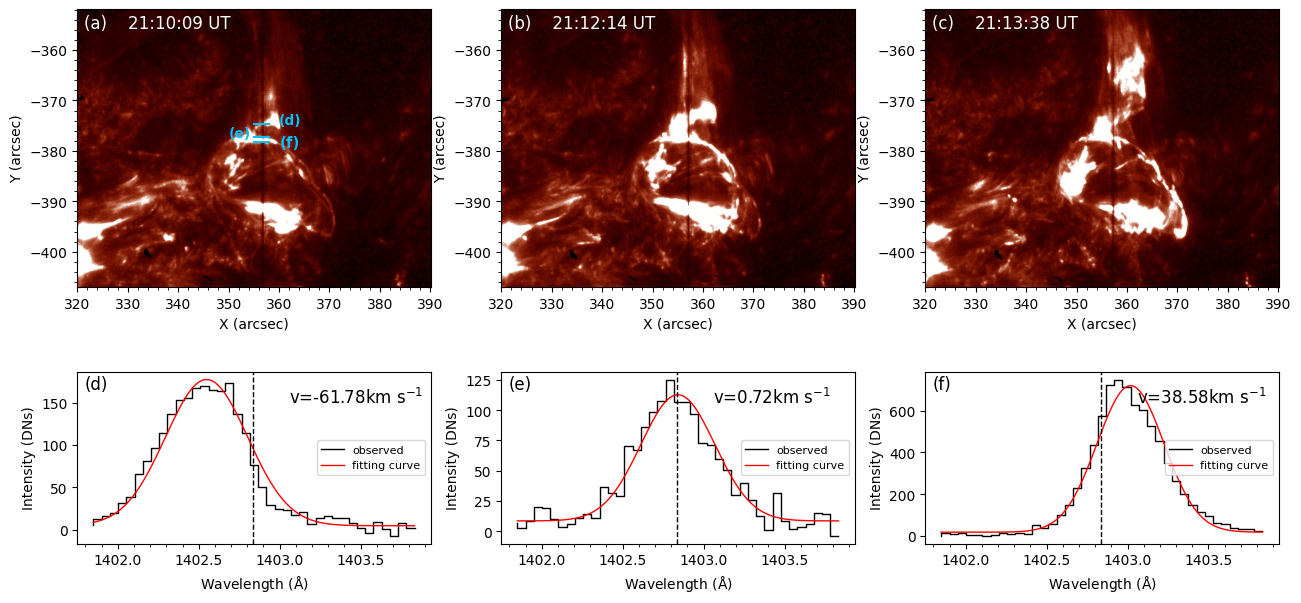

In [129]:

#---------------------------------读取数据------------------------------------
all_sji_image=readsav(r'C:\Learning\PHD1st\magnetic_reconnecion\data_process\all_sji_image.sav')['matrix_struct']
data=np.load(r'C:\Learning\PHD1st\magnetic_reconnecion\data_process\doppler_sigma_vel_nonth.npz')
doppler_vel_all=data['doppler_vel_all']
sigma_vel_nonth=data['sigma_vel_nonth']
vel_all2 = np.load(r'C:\Learning\PHD1st\magnetic_reconnecion\data_process\vel_all.npy', allow_pickle=True)
vel_all=vel_all2.item()

#-----------------------------------------画图---------------------
fig=plt.figure(figsize=(15.5,7))
gs=gridspec.GridSpec(2,1,height_ratios=[5,3],wspace=0.2,hspace=0.35)
gs_top=gridspec.GridSpecFromSubplotSpec(1,3,subplot_spec=gs[0])
ax_all=[]
for i in range(3):
    ax=fig.add_subplot(gs_top[i])
    ax_all.append(ax)

list1=[801,807,811]
list2=[400,403,405]
list3=['(a)    21:10:09 UT','(b)    21:12:14 UT','(c)    21:13:38 UT']
for i in range(3):
    ax=ax_all[i]
    ax.imshow(all_sji_image[list1[i]][0][330:,:],cmap='irissji1400',vmin=0,vmax=20,
              origin='lower',extent=[320,320+422*0.166,-407,-407+332*0.166])
    ax.set_xlabel('X (arcsec)')
    ax.set_ylabel('Y (arcsec)')
    
    ax.minorticks_on()
    pos=ax.get_position()
    #up_ax=ax.twiny()
    y_vals=np.linspace(-407,-407+332*0.166,110)
    kk=list2[i]
    cnt=kk-398
    colors='deepskyblue'
    j1,j2,j3=174,169,167
    if i==0:
        ax.plot([355,358],[solar_y[65+j1*3+1,399],solar_y[65+j1*3+1,399]],color=colors,linewidth=1.5)
        ax.plot([355,358],[solar_y[65+j2*3+1,399],solar_y[65+j2*3+1,399]],color=colors,linewidth=1.5)
        ax.plot([355,358],[solar_y[65+j3*3+1,399],solar_y[65+j3*3+1,399]],color=colors,linewidth=1.5)
        ax.text(360,solar_y[65+j1*3+1,399],'(d)',color=colors,fontsize=10,fontweight='bold')
        ax.text(350,solar_y[65+j2*3+1,399],'(e)',color=colors,fontsize=10,fontweight='bold')
        ax.text(360.1,solar_y[65+j3*3+1,399]-1,'(f)',color=colors,fontsize=11,fontweight='bold')

    cnt=0
    ax.text(0.02,0.93,list3[i],color='white',transform=ax.transAxes,fontsize=12)

#----------------------------------------------------------------------------
gs_bottom=gridspec.GridSpecFromSubplotSpec(1,3,subplot_spec=gs[1])
file_list=glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_raster\*.fits')
rsm=fits.open(file_list[403])
wave_x=np.arange(rsm[4].header['CRVAL1'],rsm[4].header['CRVAL1']+rsm[4].header['CDELT1']*rsm[4].header['NAXIS1'],rsm[4].header['CDELT1'])
cnt=0
ax2_all=[]
list4=['(d)','(e)','(f)']
for j in [j1,j2,j3]:
    spectrum = new_spectrum_all[10][j, :]#[10]表示21：10：09这个时刻
    wave_x1=wave_x[70:110]
    wave_y1=spectrum[70:110]#spectrum是没有除曝光时长的
    ax2=fig.add_subplot(gs_bottom[cnt])
    ax2_all.append(ax2)
    ax2.text(0.02,0.9,list4[cnt],color='black',transform=ax2.transAxes,fontsize=12)
    result=fit_gaussian(wave_x1,wave_y1,center_guess=ref_si_lambda,positive=True)
    amp,cen,sigma,bg=result['params']
    v=(cen-ref_si_lambda)/ref_si_lambda*2.997e5
    print(v)
    dense_x=np.linspace(wave_x1[0],wave_x1[-1],1000)
    dense_y=bg+amp*np.exp(-0.5*((dense_x-cen)/sigma)**2)
    ax2.text(0.6,0.82,r'$\mathrm{v}$'+f'={v:.2f}'+r'$\mathrm{km \ s^{-1}}$',color='black',fontsize=12,transform=ax2.transAxes)
    
    ax2.step(wave_x1,wave_y1,color='black',label='observed',linewidth=1)
    ax2.plot(dense_x,dense_y,color='red',label='fitting curve',linewidth=1)
    ax2.axvline(x=ref_si_lambda,color='black',linestyle='--',linewidth=1)
    ax2.set_xlabel(r'Wavelength $(\mathrm{\AA})$')
    ax2.set_ylabel('Intensity (DNs)')
    cnt=cnt+1
    ax2.xaxis.set_minor_locator(ticker.AutoMinorLocator())  # 给 x 轴加小刻度
    ax2.yaxis.set_minor_locator(ticker.NullLocator())   
    ax2.legend(loc='center right',fontsize=8)
plt.savefig(r'C:\Learning\PHD1st\magnetic_reconnecion\paper\fig5\iris.pdf', format='pdf', bbox_inches='tight', pad_inches=0.1)

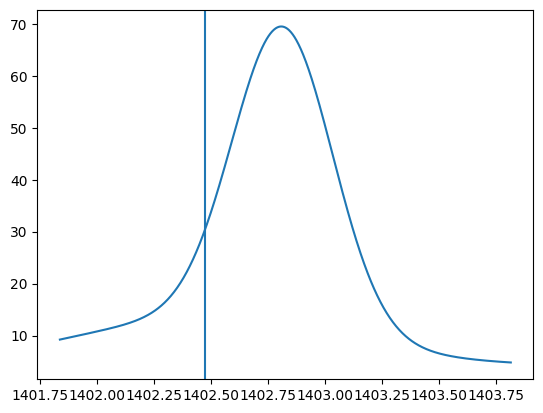

In [69]:
j=170
spectrum = new_spectrum_all[10][j, :]#[10]表示21：10：09这个时刻
wave_x1=wave_x[70:110]
wave_y1=spectrum[70:110]*3#这里我*3是为了补偿之前3个点求平均，其实应该是求和，才是计数率
if j==170:
    result=fit_double_gaussian(wave_x1,wave_y1,center1_guess=1402.6,center2_guess=1402.8,positive=True)
    amp1,cen1,sigma1,amp2,cen2,sigma2,bg=result['params']
    dense_x=np.linspace(wave_x1[0],wave_x1[-1],1000)
    dense_y=bg+amp1*np.exp(-0.5*((dense_x-cen1)/sigma1)**2)+amp2*np.exp(-0.5*((dense_x-cen2)/sigma2)**2)
    plt.plot(dense_x,dense_y)
    plt.axvline(x=1402.474)